In [2]:
DICOM_DIR="/Users/nomura/work/Dr_horaguchi/DICOM normal/1/"
NIFTI_DIR="/Users/nomura/work/Dr_horaguchi/nifti/normal/1"
!mkdir -p "$NIFTI_DIR"

!dcm2niix -z y -o "$NIFTI_DIR" "$DICOM_DIR"
!ls -lh "$NIFTI_DIR"

Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 10 DICOM file(s)
Convert 10 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2k (512x512x10x1)
Conversion required 0.235099 seconds (0.222197 for core code).
total 56736
-rw-r--r--  1 nomura  staff   947B  2月 10 04:58 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.json
-rw-r--r--  1 nomura  staff   2.3M  2月 10 04:58 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz
-rw-r--r--  1 nomura  staff   947B  2月 10 05:31 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2a.json
-rw-r--r--  1 nomura  staff   2.3M  2月 10 05:31 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2a.nii.gz
-rw-r--r--  1 nomura  staff   947B  2月 10 05:34 1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2b.json
-rw-r--r--  1 nomura  staff   2

In [3]:
!chmod u+x /Users/nomura/miniconda3/envs/totalseg/lib/python3.10/site-packages/torch/bin/torch_shm_manager

In [4]:
CT_NIFTI="/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz"
OUT_DIR="/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/"
!mkdir -p "$OUT_DIR"

!TotalSegmentator -i "$CT_NIFTI" -o "$OUT_DIR"  --fast --roi_subset gallbladder
!ls -lh "$OUT_DIR"

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.61it/s]
  Predicted in 5.78s
Resampling...
INFO: Crop is empty. Returning empty segmentation.
total 4704
-rw-r--r--  1 nomura  staff    11K  4月 23 10:26 gallbladder.nii.gz
-rw-r--r--  1 nomura  staff    21K  4月 17 08:44 liver.nii.gz
-rw-r--r--  1 nomura  staff   283K  2月 10 09:09 overlay_top001_z009.png
-rw-r--r--  1 nomura  staff   281K  2月 10 09:09 overlay_top002_z008.png
-rw-r--r--  1 nomura  staff   278K  2月 10 09:09 overlay_top003_z007.png
-rw-r--r--  1 nomura  staff   276K  2月 10 09:09 overlay_top004_z006.png
-rw-r--r--  1 nomura  staff   277K  2月 10 09:

In [5]:
import nibabel as nib, numpy as np
img = nib.load("/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz")
x = img.get_fdata()
print("shape:", x.shape)
print("min/mean/median/max:", np.min(x), np.mean(x), np.median(x), np.max(x))


shape: (512, 512, 10)
min/mean/median/max: -3024.0 -1059.787062072754 -922.0 1118.0


In [12]:
!TotalSegmentator -i "$CT_NIFTI" -o "$OUT_DIR"  \
  --roi_subset liver pancreas spleen stomach gallbladder


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.84it/s]
  Predicted in 5.70s
Resampling...
  cropping from (512, 512, 10) to (283, 217, 10)
Resampling...
  Resampled in 0.10s
Predicting part 1 of 1 ...
100%|█████████████████████████████████████████████| 2/2 [00:16<00:00,  8.47s/it]
  Predicted in 22.54s
Resampling...
Saving segmentations...
  Saved in 3.64s


In [13]:
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/gallbladder.nii.gz").get_fdata()
print("nonzero voxels:", np.count_nonzero(seg))

nonzero voxels: 5488


nonzero voxels: 78455


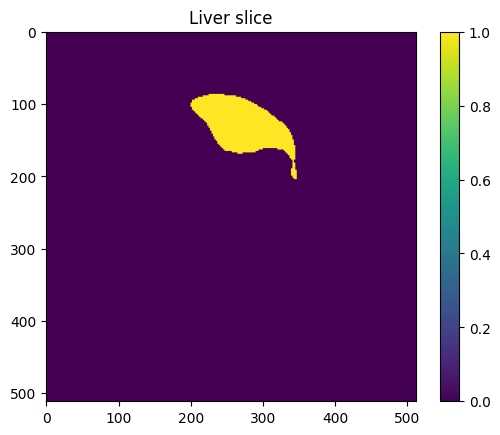

In [17]:
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/liver.nii.gz").get_fdata()
print("nonzero voxels:", np.count_nonzero(seg))
import matplotlib.pyplot as plt
plt.imshow(seg[:, :, seg.shape[2]//2])
plt.title("Liver slice")
plt.colorbar()
plt.show()

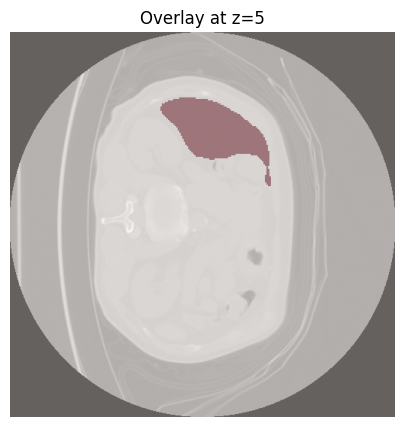

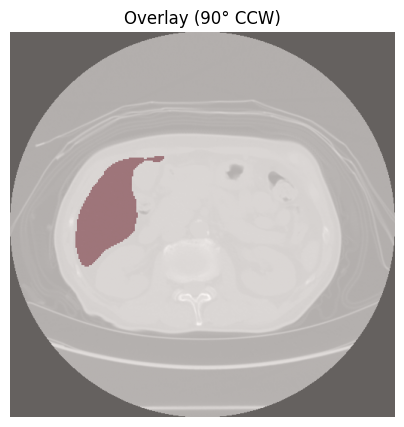

In [18]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

img = nib.load("/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz").get_fdata()
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/liver.nii.gz").get_fdata()

z = seg.shape[2]//2

plt.figure(figsize=(5,5))
plt.imshow(img[:, :, z], cmap="gray")
plt.imshow(seg[:, :, z], alpha=0.4, cmap="Reds")
plt.title(f"Overlay at z={z}")
plt.axis("off")
plt.show()

rot_img = np.rot90(img[:, :, z], k=1)
rot_seg = np.rot90(seg[:, :, z], k=1)

plt.figure(figsize=(5,5))
plt.imshow(rot_img, cmap="gray")
plt.imshow(rot_seg, alpha=0.4, cmap="Reds")
plt.title("Overlay (90° CCW)")
plt.axis("off")
plt.show()

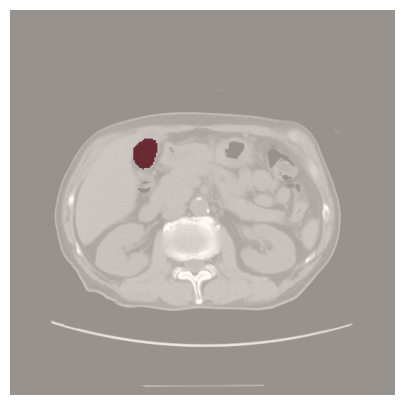

In [19]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

img = nib.load("/Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2.nii.gz").get_fdata()
seg = nib.load("/Users/nomura/work/Dr_horaguchi/seg_out/normal/1/gallbladder.nii.gz").get_fdata()

z = seg.shape[2]//2


rot_img = np.rot90(img[:, :, z], k=1)
rot_seg = np.rot90(seg[:, :, z], k=1)

plt.figure(figsize=(5,5))
plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
plt.imshow(rot_seg, alpha=0.6, cmap="Reds")
plt.axis("off")
plt.gca().set_facecolor("black")
plt.show()



In [11]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"

case_ids = [str(i) for i in range(1, 2)]

def run(cmd):
    print(">>>", " ".join(cmd))
    subprocess.run(cmd, check=True)

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print(f"skip: not found {dicom_dir}")
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("\n" + "="*60)
    print(f"Case {case_id}")

    # 1) DICOM → NIfTI（既にあればスキップ）
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        run(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

    # 2) NIfTI 自動検出（サイズ最大）
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("no nii.gz found, skip")
        continue

    ct_nifti = nii_list[0]

    # 3) TotalSegmentator
    run([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])

    # 4) overlay 画像保存（全スライス）
    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("gallbladder.nii.gz not found")
        continue
    
    img = nib.load(ct_nifti).get_fdata()
    seg = nib.load(gb_path).get_fdata()
    
    if np.count_nonzero(seg) == 0:
        print("empty gallbladder segmentation")
        continue
    
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]
    
    print(f"Gallbladder appears in slices: {nz_slices}")
    
    for z in nz_slices:
        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)
    
        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")
    
        out_png = os.path.join(out_dir, f"overlay_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)




Case 1
>>> TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2b.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/1 --fast --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 1/1 [00:06<00:00,  6.40s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
  Predicted in 5.77s
Resampling...
  cropping from (512, 512, 10) to (283, 217, 10)
Resampling...
  Resampled in 0.05s
Predicting...
  Predicted in 11.91s
Resampling...
Saving segmentations...
  Saved in 3.50s
Gallbladder appears in slices: [3 4 5 6 7 8 9]


In [37]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"

case_ids = [str(i) for i in range(1, 20)]

def run(cmd):
    print("RUN:", " ".join(cmd))
    subprocess.run(cmd, check=True)

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # 1) DICOM -> NIfTI
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        run(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])
    else:
        print("NIfTI exists, skip dcm2niix")

    # 2) NIfTI 自動検出（サイズ最大）
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("SKIP: no nii.gz found")
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # 3) TotalSegmentator
    run([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        #"--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("SKIP: gallbladder.nii.gz not found")
        continue

    img = nib.load(ct_nifti).get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("SKIP: empty gallbladder segmentation")
        continue

    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]
    print("Gallbladder slices:", nz_slices.tolist())

    # 4a) overlay 保存（全スライス）
    for z in nz_slices:
        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    # 4b) seg-only 保存（全スライス）
    for z in nz_slices:
        rot = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(4, 4))
        plt.imshow(rot)
        plt.axis("off")

        out_png = os.path.join(out_dir, f"seg_only_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("Finished case", case_id)


CASE: 1
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2b.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2b.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/1 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:14<00:00,  7.21s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 5.89s
Resampling...
  cropping from (512, 512, 10) to (283, 217, 10)
Resampling...
  Resampled in 0.10s
Predicting part 1 of 1 ...
  Predicted in 20.08s
Resampling...
Saving segmentations...
  Saved in 3.65s
Gallbladder slices: [2, 3, 4, 5, 6, 7, 8, 9]
Finished case 1
CASE: 2
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/2/2_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20170407093613_2a.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/2/2_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20170407093613_2a.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/2 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:15<00:00,  7.96s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 5.95s
Resampling...
  cropping from (512, 512, 12) to (381, 233, 12)
Resampling...
  Resampled in 0.17s
Predicting part 1 of 1 ...
  Predicted in 21.66s
Resampling...
Saving segmentations...
  Saved in 3.72s
Gallbladder slices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Finished case 2
CASE: 3
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/3/3_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20231212165949_301.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/3/3_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20231212165949_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/3 --roi_subset liver pancreas spleen stomach gallbladder


...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.17s
Predicting...
  Predicted in 5.88s
Resampling...
  cropping from (512, 512, 7) to (394, 247, 7)
Resampling...
  Resampled in 0.12s
Predicting part 1 of 1 ...
  Predicted in 16.88s
Resampling...
Saving segmentations...
  Saved in 3.59s
Gallbladder slices: [2, 3, 4, 5]
Finished case 17
CASE: 18
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/18/18_5.8_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20240906094726_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/18/18_5.8_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20240906094726_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/18 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:11<00:00,  5.63s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 7.25s
Resampling...
  cropping from (512, 512, 9) to (374, 226, 9)
Resampling...
  Resampled in 0.14s
Predicting part 1 of 1 ...
  Predicted in 16.85s
Resampling...
Saving segmentations...
  Saved in 3.60s
Gallbladder slices: [1, 2, 3, 4, 5, 6, 7]
Finished case 18
CASE: 19
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/19/19_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20231228123728_301.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/19/19_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20231228123728_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/19 --roi_subset liver pancreas spleen stomach gallbladder

100%|██████████| 2/2 [00:11<00:00,  5.76s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
  Predicted in 7.21s
Resampling...
  cropping from (512, 512, 10) to (251, 205, 10)
Resampling...
  Resampled in 0.09s
Predicting part 1 of 1 ...
  Predicted in 17.14s
Resampling...
Saving segmentations...
  Saved in 3.71s
Gallbladder slices: [1, 2, 3, 4, 5, 6, 7, 8]
Finished case 19


In [39]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"

case_ids = [str(i) for i in range(21, 81)]

def run(cmd):
    print("RUN:", " ".join(cmd))
    subprocess.run(cmd, check=True)

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # 1) DICOM -> NIfTI
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        run(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])
    else:
        print("NIfTI exists, skip dcm2niix")

    # 2) NIfTI 自動検出（サイズ最大）
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("SKIP: no nii.gz found")
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # 3) TotalSegmentator
    run([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        #"--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("SKIP: gallbladder.nii.gz not found")
        continue

    img = nib.load(ct_nifti).get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("SKIP: empty gallbladder segmentation")
        continue

    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]
    print("Gallbladder slices:", nz_slices.tolist())

    # 4a) overlay 保存（全スライス）
    for z in nz_slices:
        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    # 4b) seg-only 保存（全スライス）
    for z in nz_slices:
        rot = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(4, 4))
        plt.imshow(rot)
        plt.axis("off")

        out_png = os.path.join(out_dir, f"seg_only_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("Finished case", case_id)


CASE: 21
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/normal/21 /Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/21
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 10 DICOM file(s)
Convert 10 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/21/21_5.12_12_GSI_CHEST+ABD.+PELVIS_(CE-3Phase)_20240910112454_301 (512x512x10x1)
Conversion required 0.241756 seconds (0.230376 for core code).
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/21/21_5.12_12_GSI_CHEST+ABD.+PELVIS_(CE-3Phase)_20240910112454_301.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/21/21_5.12_12_GSI_CHEST+ABD.+PELVIS_(CE-3Phase)_20240910112454_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/21 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 1/1 [00:07<00:00,  7.38s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.20s
Predicting...
  Predicted in 6.01s
Resampling...
  cropping from (512, 512, 10) to (233, 242, 10)
Resampling...
  Resampled in 0.09s
Predicting part 1 of 1 ...
  Predicted in 13.05s
Resampling...
Saving segmentations...
  Saved in 3.58s
Gallbladder slices: [1, 2, 3, 4, 5, 6, 7, 8]
Finished case 21
CASE: 22
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/22/22_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20240126111824_301.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/22/22_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20240126111824_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/22 --roi_subset liver pancreas spleen stomach gallbl

100%|██████████| 2/2 [00:15<00:00,  7.85s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.25s
Predicting...
  Predicted in 6.03s
Resampling...
  cropping from (512, 512, 16) to (316, 250, 16)
Resampling...
  Resampled in 0.18s
Predicting part 1 of 1 ...
  Predicted in 21.69s
Resampling...
Saving segmentations...
  Saved in 3.80s
Gallbladder slices: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Finished case 22
CASE: 23
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/23/23_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20211111161318_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/23/23_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20211111161318_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/23 --roi_subset liver pancreas spleen stom

...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.20s
Predicting...
  Predicted in 7.73s
Resampling...
  cropping from (512, 512, 10) to (398, 251, 10)
Resampling...
  Resampled in 0.17s
Predicting part 1 of 1 ...
  Predicted in 31.60s
Resampling...
Saving segmentations...
  Saved in 3.69s
Gallbladder slices: [2, 3, 4, 5, 6, 7, 8]
Finished case 31
CASE: 32
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/32/32_3.4_Neck-Chest_(P+CE)_20220124094941_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/32/32_3.4_Neck-Chest_(P+CE)_20220124094941_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/32 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 4/4 [00:25<00:00,  6.31s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 7.68s
Resampling...
  cropping from (512, 512, 8) to (401, 243, 8)
Resampling...
  Resampled in 0.16s
Predicting part 1 of 1 ...
  Predicted in 31.44s
Resampling...
Saving segmentations...
  Saved in 3.79s
Gallbladder slices: [2, 3, 4, 5, 6]
Finished case 32
CASE: 33
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/33/33_5.4_Chest,Abd.,Pelvis_2phase_(1st_C_2nd_C-P)_20220412151738_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/33/33_5.4_Chest,Abd.,Pelvis_2phase_(1st_C_2nd_C-P)_20220412151738_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/33 --roi_subset liver pancreas spleen stomach gallbladder


 50%|█████     | 2/4 [00:14<00:14,  7.18s/it]Process SpawnPoolWorker-32:
Process SpawnPoolWorker-30:
Process SpawnPoolWorker-34:
Process SpawnPoolWorker-29:
Process SpawnPoolWorker-31:
Process SpawnPoolWorker-33:
Traceback (most recent call last):
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
Traceback (most recent call last):
KeyboardInterrupt
Traceba

KeyboardInterrupt: 

In [13]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"

case_ids = [str(i) for i in range(81, 100)]

def run(cmd):
    print("RUN:", " ".join(cmd))
    subprocess.run(cmd, check=True)

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # 1) DICOM -> NIfTI
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        run(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])
    else:
        print("NIfTI exists, skip dcm2niix")

    # 2) NIfTI 自動検出（サイズ最大）
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("SKIP: no nii.gz found")
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # 3) TotalSegmentator
    run([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        #"--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("SKIP: gallbladder.nii.gz not found")
        continue

    img = nib.load(ct_nifti).get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("SKIP: empty gallbladder segmentation")
        continue

    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]
    print("Gallbladder slices:", nz_slices.tolist())

    # 4a) overlay 保存（全スライス）
    for z in nz_slices:
        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    # 4b) seg-only 保存（全スライス）
    for z in nz_slices:
        rot = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(4, 4))
        plt.imshow(rot)
        plt.axis("off")

        out_png = os.path.join(out_dir, f"seg_only_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("Finished case", case_id)


CASE: 81
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/normal/81 /Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/81
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 14 DICOM file(s)
Convert 9 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/81/81_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20251216115410_301 (512x512x9x1)
Convert 5 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/81/81_336_20241216092609_2 (512x512x5x1)
Conversion required 0.287163 seconds (0.269387 for core code).
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/81/81_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20251216115410_301.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/81/81_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20251216115410_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/81 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 1/1 [00:08<00:00,  8.03s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.17s
Predicting...
  Predicted in 5.66s
Resampling...
  cropping from (512, 512, 9) to (264, 229, 9)
Resampling...
  Resampled in 0.08s
Predicting part 1 of 1 ...
  Predicted in 13.37s
Resampling...
Saving segmentations...
  Saved in 3.43s
Gallbladder slices: [0, 1, 2, 3, 4, 5, 6, 7]
Finished case 81
CASE: 82
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/normal/82 /Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/82
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 16 DICOM file(s)
Convert 11 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/82/82_5.8_Chest,Abd.,Pelvis_1phase_+Direct_MP

100%|██████████| 2/2 [00:13<00:00,  6.66s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
  Predicted in 7.10s
Resampling...
  cropping from (512, 512, 11) to (251, 189, 11)
Resampling...
  Resampled in 0.09s
Predicting part 1 of 1 ...
  Predicted in 18.75s
Resampling...
Saving segmentations...
  Saved in 3.59s
Gallbladder slices: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Finished case 82
CASE: 83
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/normal/83 /Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/83
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 17 DICOM file(s)
Convert 12 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/83/83_B6_It!A9_HW!J_(BFF_B!K_(B_20250829

...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.16s
Predicting...
  Predicted in 7.17s
Resampling...
  cropping from (512, 512, 4) to (348, 258, 4)
Resampling...
  Resampled in 0.10s
Predicting part 1 of 1 ...
  Predicted in 25.86s
Resampling...
Saving segmentations...
  Saved in 3.53s
Gallbladder slices: [1, 2, 3]
Finished case 97
CASE: 98
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/normal/98 /Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/98
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 12 DICOM file(s)
Convert 12 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/98/98_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_202504231253

100%|██████████| 2/2 [00:11<00:00,  5.62s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 7.19s
Resampling...
  cropping from (512, 512, 12) to (361, 224, 12)
Resampling...
  Resampled in 0.17s
Predicting part 1 of 1 ...
  Predicted in 16.86s
Resampling...
Saving segmentations...
  Saved in 3.55s
Gallbladder slices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Finished case 98
CASE: 99
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/normal/99 /Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/99
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 9 DICOM file(s)
Convert 9 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/normal/99/99_5.8_Chest,Abd.,Pelvis_1ph

100%|██████████| 4/4 [00:20<00:00,  5.00s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 5.83s
Resampling...
  cropping from (512, 512, 9) to (431, 283, 9)
Resampling...
  Resampled in 0.18s
Predicting part 1 of 1 ...
  Predicted in 25.53s
Resampling...
Saving segmentations...
  Saved in 3.52s
Gallbladder slices: [3, 4, 5, 6, 7, 8]
Finished case 99


In [14]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"

case_ids = [str(i) for i in range(81, 100)]

failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    """
    NIfTIのz index (0-based) -> 上から何枚目 (1-based)
    z_axis_code は aff2axcodes(...)[2] の 'S' or 'I' を想定。
    """
    if z_axis_code == "S":
        # x,y,z が ('R','A','S') のように z+ が Superior
        # z=0 が Inferior(下)側なので、上からは Z-z
        return Z - z
    if z_axis_code == "I":
        # z+ が Inferior
        # z=0 が Superior(上)側なので、上からは z+1
        return z + 1
    return -1  # 想定外

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出（サイズ最大をCT本体として採用） ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- affine（座標系）確認 ----
    img_nii = nib.load(ct_nifti)
    axcodes = aff2axcodes(img_nii.affine)   # (x,y,z) e.g. ('R','A','S')
    z_axis  = axcodes[2]
    Z = img_nii.shape[2]
    print("Axis codes (x,y,z):", axcodes)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    # 入力CTとセグを読み込む
    img = img_nii.get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # 胆嚢が存在するzだけを抽出
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0].tolist()
    print("Gallbladder z indices:", nz_slices)

    # ---- 保存（overlay + seg-only）----
    # 表示用の回転（見た目だけ）：90° CCW
    for z in nz_slices:
        from_top = z_to_from_top(z, Z, z_axis)
        if from_top == -1:
            # 想定外の向きなら z のみで保存（落とさない）
            from_top = z + 1

        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        # overlay
        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

        # seg-only（重ねない）
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(np.rot90(seg[:, :, z], k=1))
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))
print("FAILED CASES:", failed_cases)


CASE: 81
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/81 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/81
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 10 DICOM file(s)
Convert 10 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/81/81_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20251026013911_301 (512x512x10x1)
Conversion required 0.212098 seconds (0.203611 for core code).
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/81/81_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20251026013911_301.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/81/81_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20251026013911_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/81 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:11<00:00,  5.70s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
  Predicted in 7.17s
Resampling...
  cropping from (512, 512, 10) to (367, 244, 10)
Resampling...
  Resampled in 0.15s
Predicting part 1 of 1 ...
  Predicted in 17.06s
Resampling...
Saving segmentations...
  Saved in 3.56s
Gallbladder z indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
SUCCESS: 81
CASE: 82
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/82 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/82
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 11 DICOM file(s)
Convert 11 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/82/82_5.10_10_GSI_CHEST+A

100%|██████████| 2/2 [00:11<00:00,  5.60s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.20s
Predicting...
  Predicted in 5.85s
Resampling...
  cropping from (512, 512, 11) to (290, 212, 11)
Resampling...
  Resampled in 0.10s
Predicting part 1 of 1 ...
  Predicted in 16.74s
Resampling...
Saving segmentations...
  Saved in 3.53s
Gallbladder z indices: [2, 3, 4, 5, 6, 7, 8, 9]
SUCCESS: 82
CASE: 83
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/83 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/83
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 6 DICOM file(s)
Convert 6 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/83/83_5.8_Chest,Abd.,Pelvis_1phas

...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.23s
Predicting...
  Predicted in 7.22s
Resampling...
  cropping from (512, 512, 15) to (411, 270, 15)
Resampling...
  Resampled in 0.28s
Predicting part 1 of 1 ...
  Predicted in 24.53s
Resampling...
Saving segmentations...
  Saved in 3.61s
Gallbladder z indices: [5, 6, 7, 8, 9, 10, 11, 12, 13]
SUCCESS: 97
CASE: 98
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/98 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/98
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 14 DICOM file(s)
Convert 14 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/98/98_6.1_Abdomen-pelvis

100%|██████████| 2/2 [00:10<00:00,  5.28s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.22s
Predicting...
  Predicted in 5.81s
Resampling...
  cropping from (512, 512, 14) to (425, 260, 14)
Resampling...
  Resampled in 0.23s
Predicting part 1 of 1 ...
  Predicted in 16.13s
Resampling...
Saving segmentations...
  Saved in 3.57s
Gallbladder z indices: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
SUCCESS: 98
CASE: 99
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/99 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/99
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 12 DICOM file(s)
Convert 12 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/99/99_5.6_Chest

100%|██████████| 4/4 [00:18<00:00,  4.60s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 7.15s
Resampling...
  cropping from (512, 512, 12) to (390, 267, 12)
Resampling...
  Resampled in 0.20s
Predicting part 1 of 1 ...
  Predicted in 24.11s
Resampling...
Saving segmentations...
  Saved in 3.55s
Gallbladder z indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
SUCCESS: 99
SUCCESS COUNT: 18
FAIL COUNT: 1
FAILED CASES: [('92', 'empty_gallbladder')]


In [11]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"

case_ids = [str(i) for i in range(73, 74)]

failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    """
    NIfTIのz index (0-based) -> 上から何枚目 (1-based)
    z_axis_code は aff2axcodes(...)[2] の 'S' or 'I' を想定。
    """
    if z_axis_code == "S":
        # x,y,z が ('R','A','S') のように z+ が Superior
        # z=0 が Inferior(下)側なので、上からは Z-z
        return Z - z
    if z_axis_code == "I":
        # z+ が Inferior
        # z=0 が Superior(上)側なので、上からは z+1
        return z + 1
    return -1  # 想定外

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出（サイズ最大をCT本体として採用） ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- affine（座標系）確認 ----
    img_nii = nib.load(ct_nifti)
    axcodes = aff2axcodes(img_nii.affine)   # (x,y,z) e.g. ('R','A','S')
    z_axis  = axcodes[2]
    Z = img_nii.shape[2]
    print("Axis codes (x,y,z):", axcodes)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        #"--roi_subset",
        #"liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    # 入力CTとセグを読み込む
    img = img_nii.get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # 胆嚢が存在するzだけを抽出
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0].tolist()
    print("Gallbladder z indices:", nz_slices)

    # ---- 保存（overlay + seg-only）----
    # 表示用の回転（見た目だけ）：90° CCW
    for z in nz_slices:
        from_top = z_to_from_top(z, Z, z_axis)
        if from_top == -1:
            # 想定外の向きなら z のみで保存（落とさない）
            from_top = z + 1

        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        # overlay
        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_top{from_top:03d}_z{z:03d}.png")
        #plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

        # seg-only（重ねない）
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(np.rot90(seg[:, :, z], k=1))
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_top{from_top:03d}_z{z:03d}.png")
        #plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))
print("FAILED CASES:", failed_cases)


CASE: 73
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/73/73_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20231020114216_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/73/73_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20231020114216_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/73


100%|██████████| 9/9 [00:48<00:00,  5.43s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Resampling...
  Resampled in 0.41s
Predicting part 1 of 5 ...
Predicting part 2 of 5 ...
Predicting part 3 of 5 ...
Predicting part 4 of 5 ...
Predicting part 5 of 5 ...
  Predicted in 279.36s
Resampling...
Saving segmentations...
  Saved in 3.98s
Gallbladder z indices: [2, 3, 4, 5]
SUCCESS: 73
SUCCESS COUNT: 1
FAIL COUNT: 0
FAILED CASES: []


In [15]:
path = f"{out_dir}/gallbladder.nii.gz"
nii = nib.load(path)
data = nii.get_fdata()

print(data.shape)   # 例: (512, 512, 100)
print(data.min(), data.max())

(512, 512, 11)
0.0 1.0


In [17]:
import numpy as np

slices = []
for i in range(data.shape[2]):
    if np.sum(data[:, :, i]) > 0:
        slices.append(i)

print("胆嚢があるスライス:", slices[:10], "...", len(slices))

胆嚢があるスライス: [2, 3, 4, 5] ... 4


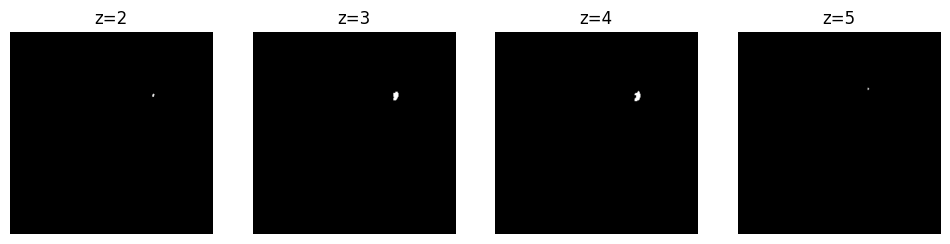

In [18]:
import matplotlib.pyplot as plt

slices = [2, 3, 4, 5]

plt.figure(figsize=(12, 3))
for i, z in enumerate(slices):
    plt.subplot(1, len(slices), i+1)
    plt.imshow(data[:, :, z], cmap="gray")
    plt.title(f"z={z}")
    plt.axis("off")

plt.show()

In [9]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"

case_ids = [str(i) for i in range(73, 74)]

failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    """
    NIfTIのz index (0-based) -> 上から何枚目 (1-based)
    z_axis_code は aff2axcodes(...)[2] の 'S' or 'I' を想定。
    """
    if z_axis_code == "S":
        # x,y,z が ('R','A','S') のように z+ が Superior
        # z=0 が Inferior(下)側なので、上からは Z-z
        return Z - z
    if z_axis_code == "I":
        # z+ が Inferior
        # z=0 が Superior(上)側なので、上からは z+1
        return z + 1
    return -1  # 想定外

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出（サイズ最大をCT本体として採用） ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- affine（座標系）確認 ----
    img_nii = nib.load(ct_nifti)
    axcodes = aff2axcodes(img_nii.affine)   # (x,y,z) e.g. ('R','A','S')
    z_axis  = axcodes[2]
    Z = img_nii.shape[2]
    print("Axis codes (x,y,z):", axcodes)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    # 入力CTとセグを読み込む
    img = img_nii.get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # 胆嚢が存在するzだけを抽出
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0].tolist()
    print("Gallbladder z indices:", nz_slices)

    # ---- 保存（overlay + seg-only）----
    # 表示用の回転（見た目だけ）：90° CCW
    for z in nz_slices:
        from_top = z_to_from_top(z, Z, z_axis)
        if from_top == -1:
            # 想定外の向きなら z のみで保存（落とさない）
            from_top = z + 1

        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        # overlay
        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

        # seg-only（重ねない）
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(np.rot90(seg[:, :, z], k=1))
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))
print("FAILED CASES:", failed_cases)


CASE: 73
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/73/73_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20231020114216_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/73/73_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20231020114216_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/73 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 4/4 [00:33<00:00,  8.47s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
  Predicted in 5.92s
Resampling...
  cropping from (512, 512, 11) to (429, 290, 11)
Resampling...
  Resampled in 0.20s
Predicting part 1 of 1 ...
  Predicted in 39.57s
Resampling...
Saving segmentations...
  Saved in 3.58s
Empty gallbladder segmentation
SUCCESS COUNT: 0
FAIL COUNT: 1
FAILED CASES: [('73', 'empty_gallbladder')]


CASE: 73

--- TRY: 73_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20231020114216_2.nii.gz


100%|██████████| 4/4 [00:31<00:00,  7.99s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
  Predicted in 5.84s
Resampling...
  cropping from (512, 512, 11) to (429, 290, 11)
Resampling...
  Resampled in 0.20s
Predicting part 1 of 1 ...
  Predicted in 37.61s
Resampling...
Saving segmentations...
  Saved in 3.74s
liver: vox=126801
spleen: vox=30724
pancreas: vox=14826
stomach: vox=15888
gallbladder: vox=0
Show z = 5


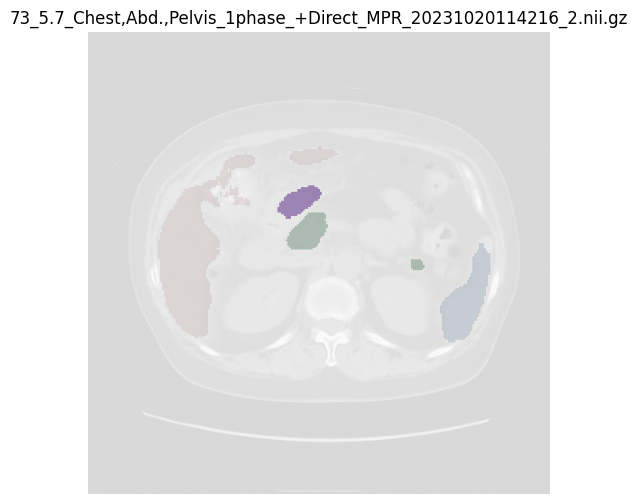

In [10]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_tmp"

case_ids = ["73"]


def run_ok(cmd):
    r = subprocess.run(cmd)
    return r.returncode == 0


organs = ["liver", "spleen", "pancreas", "stomach", "gallbladder"]


for case_id in case_ids:
    print("="*50)
    print("CASE:", case_id)

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_base  = os.path.join(BASE_OUT, case_id)

    nii_list = sorted(glob.glob(os.path.join(nifti_dir, "*.nii.gz")))

    for i, nii_path in enumerate(nii_list):
        print("\n--- TRY:", os.path.basename(nii_path))

        out_dir = os.path.join(out_base, f"try_{i}")
        os.makedirs(out_dir, exist_ok=True)

        # ---- TotalSegmentator ----
        ok = run_ok([
            "TotalSegmentator",
            "-i", nii_path,
            "-o", out_dir,
            "--roi_subset", *organs
        ])

        if not ok:
            print("TS failed")
            continue

        img = nib.load(nii_path).get_fdata()

        segs = {}
        for organ in organs:
            p = os.path.join(out_dir, f"{organ}.nii.gz")
            if os.path.exists(p):
                segs[organ] = nib.load(p).get_fdata()
                print(f"{organ}: vox={np.count_nonzero(segs[organ])}")
            else:
                segs[organ] = None
                print(f"{organ}: none")

        # ---- 表示用slice選択 ----
        # どれか臓器があるスライス
        combined = np.zeros_like(img)
        for organ in organs:
            if segs[organ] is not None:
                combined += segs[organ]

        z_candidates = np.where(np.any(combined > 0, axis=(0,1)))[0]

        if len(z_candidates) == 0:
            print("No organ found at all")
            continue

        z = z_candidates[len(z_candidates)//2]  # 真ん中

        print(f"Show z = {z}")

        # ---- 可視化 ----
        plt.figure(figsize=(6,6))
        plt.imshow(np.rot90(img[:,:,z]), cmap="gray", vmin=-200, vmax=300)

        # 色を変えて重ねる
        colors = {
            "liver": "Reds",
            "spleen": "Blues",
            "pancreas": "Greens",
            "stomach": "Purples",
            "gallbladder": "Oranges"
        }

        for organ in organs:
            if segs[organ] is not None and np.any(segs[organ][:,:,z] > 0):
                plt.imshow(
                    np.rot90(segs[organ][:,:,z]),
                    alpha=0.4,
                    cmap=colors[organ]
                )

        plt.title(os.path.basename(nii_path))
        plt.axis("off")
        plt.show()

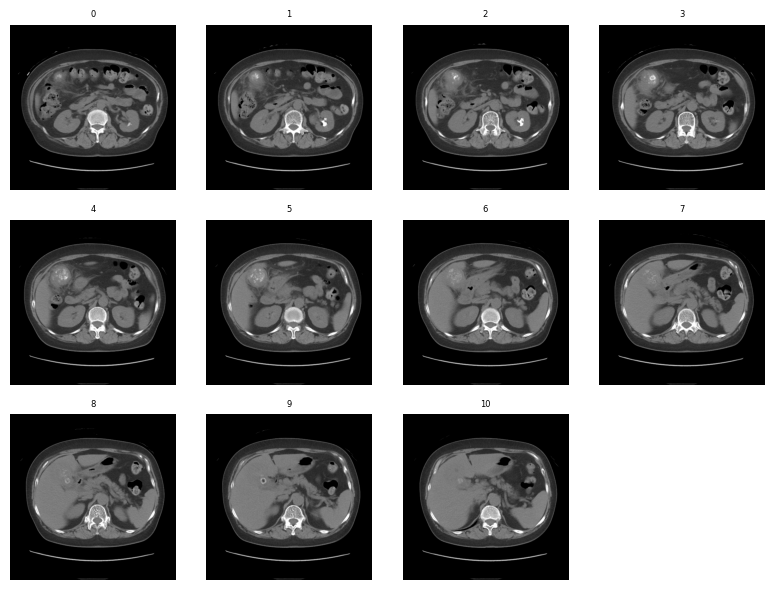

In [11]:
import math
import matplotlib.pyplot as plt
import numpy as np

Z = img.shape[2]

# グリッドサイズ自動決定（なるべく正方形）
cols = int(math.ceil(math.sqrt(Z)))
rows = int(math.ceil(Z / cols))

plt.figure(figsize=(cols*2, rows*2))

for z in range(Z):
    plt.subplot(rows, cols, z+1)
    plt.imshow(np.rot90(img[:,:,z]), cmap="gray", vmin=-200, vmax=300)
    plt.title(f"{z}", fontsize=6)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"

case_ids = [str(i) for i in range(1, 81)]

failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    """
    NIfTIのz index (0-based) -> 上から何枚目 (1-based)
    z_axis_code は aff2axcodes(...)[2] の 'S' or 'I' を想定。
    """
    if z_axis_code == "S":
        # x,y,z が ('R','A','S') のように z+ が Superior
        # z=0 が Inferior(下)側なので、上からは Z-z
        return Z - z
    if z_axis_code == "I":
        # z+ が Inferior
        # z=0 が Superior(上)側なので、上からは z+1
        return z + 1
    return -1  # 想定外

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出（サイズ最大をCT本体として採用） ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- affine（座標系）確認 ----
    img_nii = nib.load(ct_nifti)
    axcodes = aff2axcodes(img_nii.affine)   # (x,y,z) e.g. ('R','A','S')
    z_axis  = axcodes[2]
    Z = img_nii.shape[2]
    print("Axis codes (x,y,z):", axcodes)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    # 入力CTとセグを読み込む
    img = img_nii.get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # 胆嚢が存在するzだけを抽出
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0].tolist()
    print("Gallbladder z indices:", nz_slices)

    # ---- 保存（overlay + seg-only）----
    # 表示用の回転（見た目だけ）：90° CCW
    for z in nz_slices:
        from_top = z_to_from_top(z, Z, z_axis)
        if from_top == -1:
            # 想定外の向きなら z のみで保存（落とさない）
            from_top = z + 1

        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        # overlay
        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

        # seg-only（重ねない）
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(np.rot90(seg[:, :, z], k=1))
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))
print("FAILED CASES:", failed_cases)


CASE: 1
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/1/1_6.14_Abd.,Pelvis_(1phase)_20190923151859_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/1/1_6.14_Abd.,Pelvis_(1phase)_20190923151859_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/1 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:13<00:00,  6.84s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.23s
Predicting...
  Predicted in 5.75s
Resampling...
  cropping from (512, 512, 18) to (407, 247, 17)
Resampling...
  Resampled in 0.22s
Predicting part 1 of 1 ...
  Predicted in 19.44s
Resampling...
Saving segmentations...
  Saved in 3.80s
Gallbladder z indices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
SUCCESS: 1
CASE: 2
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/2/2_5.66_66_GSI_CHEST+ABD.+PELVIS_(CE-4Phase_for_Panc)_GIFU_20191119085136_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/2/2_5.66_66_GSI_CHEST+ABD.+PELVIS_(CE-4Phase_for_Panc)_GIFU_20191119085136_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/

100%|██████████| 4/4 [00:21<00:00,  5.48s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.24s
Predicting...
  Predicted in 7.71s
Resampling...
  cropping from (512, 512, 17) to (396, 292, 17)
Resampling...
  Resampled in 0.30s
Predicting part 1 of 1 ...
  Predicted in 27.71s
Resampling...
Saving segmentations...
  Saved in 3.70s
Gallbladder z indices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
SUCCESS: 2
CASE: 3
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/3/3_6.14_Abd.,Pelvis_(1phase)_20191219074039_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/3/3_6.14_Abd.,Pelvis_(1phase)_20191219074039_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/3 --roi_subset liver pancreas spleen stomach g

...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.23s
Predicting...
  Predicted in 7.41s
Resampling...
  cropping from (512, 512, 15) to (344, 244, 15)
Resampling...
  Resampled in 0.20s
Predicting part 1 of 1 ...
  Predicted in 18.37s
Resampling...
Saving segmentations...
  Saved in 3.70s
Gallbladder z indices: [9, 10, 11, 12, 13]
SUCCESS: 78
CASE: 79
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/79/79_6.18_18_GSI_ABD.+PELVIS_(CE-4Phase_SP+5sec_for_Panc)_20240507140658_301.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/79/79_6.18_18_GSI_ABD.+PELVIS_(CE-4Phase_SP+5sec_for_Panc)_20240507140658_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/79 --roi

100%|██████████| 4/4 [00:21<00:00,  5.26s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 5.92s
Resampling...
  cropping from (512, 512, 8) to (406, 306, 8)
Resampling...
  Resampled in 0.17s
Predicting part 1 of 1 ...
  Predicted in 26.77s
Resampling...
Saving segmentations...
  Saved in 3.68s
Gallbladder z indices: [0, 1, 2, 3, 4, 5, 6]
SUCCESS: 79
CASE: 80
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/80/80_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20240129082031_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/80/80_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20240129082031_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/80 --roi_subset liver pancreas splee

100%|██████████| 4/4 [00:21<00:00,  5.42s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 7.50s
Resampling...
  cropping from (512, 512, 8) to (375, 275, 8)
Resampling...
  Resampled in 0.15s
Predicting part 1 of 1 ...
  Predicted in 27.47s
Resampling...
Saving segmentations...
  Saved in 3.70s
Gallbladder z indices: [0, 1, 2, 3, 4, 5, 6, 7]
SUCCESS: 80
SUCCESS COUNT: 76
FAIL COUNT: 4
FAILED CASES: [('21', 'empty_gallbladder'), ('73', 'dicom_dir_not_found'), ('76', 'dicom_dir_not_found'), ('77', 'dicom_dir_not_found')]


In [50]:
# 胆嚢炎（または正常）: 胆嚢マスクBBox + marginでCTをクロップし、
# 各スライスを「反時計回りに90度回転」して .npy と .png で保存する

import os, glob, json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"
BASE_SAVE  = "/Users/nomura/work/Dr_horaguchi/cropped_slices/cholecystitis"

case_ids = [str(i) for i in range(1, 81)]

MARGIN_XY = 30
SAVE_PNG = True
WIN_MIN, WIN_MAX = -200, 300  # PNG用window
ROTATE_CCW_90 = True          # ★反時計回り90度回転する

failed = []
saved_cases = []

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    # 上から何枚目 (1-based)
    if z_axis_code == "S":
        return Z - z
    if z_axis_code == "I":
        return z + 1
    return z + 1  # 想定外は配列順で

for case_id in case_ids:
    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)

    # CTを探す（サイズ最大）
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        failed.append((case_id, "no_ct_nifti"))
        continue
    ct_path = nii_list[0]

    # 胆嚢マスク
    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        failed.append((case_id, "no_gallbladder_mask"))
        continue

    # load
    img_nii = nib.load(ct_path)
    seg_nii = nib.load(gb_path)
    img = img_nii.get_fdata()
    seg = seg_nii.get_fdata()

    if img.shape != seg.shape:
        failed.append((case_id, "shape_mismatch"))
        continue
    if np.count_nonzero(seg) == 0:
        failed.append((case_id, "empty_mask"))
        continue

    X, Y, Z = seg.shape
    axcodes = aff2axcodes(img_nii.affine)
    z_axis  = axcodes[2]

    # XY BBox（胆嚢マスクから） + margin
    xs, ys, zs = np.where(seg > 0)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    cx0 = clamp(x0 - MARGIN_XY, 0, X - 1)
    cx1 = clamp(x1 + MARGIN_XY, 0, X - 1)
    cy0 = clamp(y0 - MARGIN_XY, 0, Y - 1)
    cy1 = clamp(y1 + MARGIN_XY, 0, Y - 1)

    save_dir = os.path.join(BASE_SAVE, case_id)
    os.makedirs(save_dir, exist_ok=True)

    # 各スライスで crop -> 回転 -> 保存
    for z in range(Z):
        ct_crop_2d = img[cx0:cx1+1, cy0:cy1+1, z].astype(np.float32)

        # ★ 反時計回りに90度回転（npyもpngもこれが効く）
        if ROTATE_CCW_90:
            ct_crop_2d = np.rot90(ct_crop_2d, k=1)

        top = z_to_from_top(z, Z, z_axis)

        # 1) 生のHU（float32）を .npy で保存（回転済み）
        npy_path = os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.npy")
        np.save(npy_path, ct_crop_2d)

        # 2) PNG（windowして0..255にして保存）（回転済み）
        if SAVE_PNG:
            x = np.clip(ct_crop_2d, WIN_MIN, WIN_MAX)
            x = (x - WIN_MIN) / (WIN_MAX - WIN_MIN + 1e-8)  # 0..1
            x = (x * 255).astype(np.uint8)

            png_path = os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.png")
            plt.imsave(png_path, x, cmap="gray")

    # メタ情報も残す（回転情報も追記）
    meta = {
        "case_id": case_id,
        "ct_path": ct_path,
        "mask_path": gb_path,
        "axcodes": list(axcodes),
        "shape": [int(X), int(Y), int(Z)],
        "crop_xy": {"x0": int(cx0), "x1": int(cx1), "y0": int(cy0), "y1": int(cy1)},
        "margin_xy": int(MARGIN_XY),
        "png_window": {"min": float(WIN_MIN), "max": float(WIN_MAX)},
        "rotation": "CCW_90" if ROTATE_CCW_90 else "none",
        "note": "Saved each z-slice crop as 2D array after rotation. NPY is float32 HU crop; PNG is windowed uint8."
    }
    with open(os.path.join(save_dir, "meta.json"), "w") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(
        f"Saved cropped slices for case {case_id} | Z={Z} | axcodes={axcodes} | "
        f"crop_before_rot={(cx1-cx0+1, cy1-cy0+1)} | "
        f"crop_after_rot={(cy1-cy0+1, cx1-cx0+1) if ROTATE_CCW_90 else (cx1-cx0+1, cy1-cy0+1)}"
    )
    saved_cases.append(case_id)

print("DONE")
print("SAVED CASES:", len(saved_cases))
print("FAILED:", len(failed))
print("FAILED CASES (first 30):", failed[:30])


Saved cropped slices for case 1 | Z=18 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(126), np.int64(143)) | crop_after_rot=(np.int64(143), np.int64(126))
Saved cropped slices for case 2 | Z=17 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(143), np.int64(147)) | crop_after_rot=(np.int64(147), np.int64(143))
Saved cropped slices for case 3 | Z=9 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(150), np.int64(152)) | crop_after_rot=(np.int64(152), np.int64(150))
Saved cropped slices for case 4 | Z=24 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(137), np.int64(153)) | crop_after_rot=(np.int64(153), np.int64(137))
Saved cropped slices for case 5 | Z=12 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(143), np.int64(133)) | crop_after_rot=(np.int64(133), np.int64(143))
Saved cropped slices for case 6 | Z=21 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(126), np.int64(122)) | crop_after_rot=(np.int64(122), np.int64(126))
Saved cropped slices for case

In [53]:
import os, glob, json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"
BASE_SAVE  = "/Users/nomura/work/Dr_horaguchi/cropped_slices/cholecystitis"

case_ids = [str(i) for i in range(1, 81)]

MARGIN_XY = 30
WIN_MIN, WIN_MAX = -200, 300
ROTATE_CCW_90 = True

# 赤強調パラメータ
OVERLAY_ALPHA = 0.6

failed = []

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def z_to_from_top(z, Z, z_axis_code):
    if z_axis_code == "S":
        return Z - z
    return z + 1

def window_to_uint8(x, wmin, wmax):
    x = np.clip(x, wmin, wmax)
    x = (x - wmin) / (wmax - wmin + 1e-8)
    return (x * 255).astype(np.uint8)

for case_id in case_ids:
    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)

    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize, reverse=True
    )
    if not nii_list:
        failed.append((case_id, "no_ct"))
        continue

    ct_path = nii_list[0]
    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        failed.append((case_id, "no_mask"))
        continue

    img_nii = nib.load(ct_path)
    seg_nii = nib.load(gb_path)

    img = img_nii.get_fdata()
    seg = seg_nii.get_fdata()

    if img.shape != seg.shape or np.count_nonzero(seg) == 0:
        failed.append((case_id, "invalid"))
        continue

    X, Y, Z = seg.shape
    axcodes = aff2axcodes(img_nii.affine)
    z_axis = axcodes[2]

    xs, ys, _ = np.where(seg > 0)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    cx0 = clamp(x0 - MARGIN_XY, 0, X - 1)
    cx1 = clamp(x1 + MARGIN_XY, 0, X - 1)
    cy0 = clamp(y0 - MARGIN_XY, 0, Y - 1)
    cy1 = clamp(y1 + MARGIN_XY, 0, Y - 1)

    save_dir = os.path.join(BASE_SAVE, case_id)
    os.makedirs(save_dir, exist_ok=True)

    for z in range(Z):
        ct = img[cx0:cx1+1, cy0:cy1+1, z].astype(np.float32)
        gb = seg[cx0:cx1+1, cy0:cy1+1, z] > 0

        if ROTATE_CCW_90:
            ct = np.rot90(ct, 1)
            gb = np.rot90(gb, 1)

        top = z_to_from_top(z, Z, z_axis)

        # === npy ===
        np.save(
            os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.npy"),
            ct
        )

        base = window_to_uint8(ct, WIN_MIN, WIN_MAX)

        # === ① 通常CT ===
        plt.imsave(
            os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.png"),
            base, cmap="gray"
        )

        # === ② 赤強調（別画像）===
        rgb = np.stack([base, base, base], axis=-1).astype(np.float32) / 255.0
        rgb[gb] = (1 - OVERLAY_ALPHA) * rgb[gb] + OVERLAY_ALPHA * np.array([1, 0, 0])
        plt.imsave(
            os.path.join(save_dir, f"ct_overlay_red_top{top:03d}_z{z:03d}.png"),
            np.clip(rgb, 0, 1)
        )

        # === ③ 黒穴抜き（別画像）===
        hole = base.copy()
        hole[gb] = 0
        plt.imsave(
            os.path.join(save_dir, f"ct_hole_black_top{top:03d}_z{z:03d}.png"),
            hole, cmap="gray"
        )

    print(f"saved case {case_id}")

print("DONE")
print("FAILED:", failed[:20])


saved case 1
saved case 2
saved case 3
saved case 4
saved case 5
saved case 6
saved case 7
saved case 8
saved case 9
saved case 10
saved case 11
saved case 12
saved case 13
saved case 14
saved case 15
saved case 16
saved case 17
saved case 18
saved case 19
saved case 20
saved case 22
saved case 23
saved case 24
saved case 25
saved case 26
saved case 27
saved case 28
saved case 29
saved case 30
saved case 31
saved case 32
saved case 33
saved case 34
saved case 35
saved case 36
saved case 37
saved case 38
saved case 39
saved case 40
saved case 41
saved case 42
saved case 43
saved case 44
saved case 45
saved case 46
saved case 47
saved case 48
saved case 49
saved case 50
saved case 51
saved case 52
saved case 53
saved case 54
saved case 55
saved case 56
saved case 57
saved case 58
saved case 59
saved case 60
saved case 61
saved case 62
saved case 63
saved case 64
saved case 65
saved case 66
saved case 67
saved case 68
saved case 69
saved case 70
saved case 71
saved case 72
saved case 74
s

In [46]:
## 正常　これを使用 20で止まってしまう

import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"


case_ids = [str(i) for i in range(1, 81)]

failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    """
    NIfTIのz index (0-based) -> 上から何枚目 (1-based)
    z_axis_code は aff2axcodes(...)[2] の 'S' or 'I' を想定。
    """
    if z_axis_code == "S":
        # x,y,z が ('R','A','S') のように z+ が Superior
        # z=0 が Inferior(下)側なので、上からは Z-z
        return Z - z
    if z_axis_code == "I":
        # z+ が Inferior
        # z=0 が Superior(上)側なので、上からは z+1
        return z + 1
    return -1  # 想定外

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出（サイズ最大をCT本体として採用） ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- affine（座標系）確認 ----
    img_nii = nib.load(ct_nifti)
    axcodes = aff2axcodes(img_nii.affine)   # (x,y,z) e.g. ('R','A','S')
    z_axis  = axcodes[2]
    Z = img_nii.shape[2]
    print("Axis codes (x,y,z):", axcodes)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    # 入力CTとセグを読み込む
    img = img_nii.get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # 胆嚢が存在するzだけを抽出
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0].tolist()
    print("Gallbladder z indices:", nz_slices)

    # ---- 保存（overlay + seg-only）----
    # 表示用の回転（見た目だけ）：90° CCW
    for z in nz_slices:
        from_top = z_to_from_top(z, Z, z_axis)
        if from_top == -1:
            # 想定外の向きなら z のみで保存（落とさない）
            from_top = z + 1

        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        # overlay
        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

        # seg-only（重ねない）
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(np.rot90(seg[:, :, z], k=1))
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))
print("FAILED CASES:", failed_cases)


CASE: 1
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2b.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/1/1_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20171226153222_2b.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/1 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:13<00:00,  6.53s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 5.83s
Resampling...
  cropping from (512, 512, 10) to (283, 217, 10)
Resampling...
  Resampled in 0.10s
Predicting part 1 of 1 ...
  Predicted in 18.68s
Resampling...
Saving segmentations...
  Saved in 3.59s
Gallbladder z indices: [2, 3, 4, 5, 6, 7, 8, 9]
SUCCESS: 1
CASE: 2
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/2/2_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20170407093613_2a.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/2/2_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20170407093613_2a.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/2 --roi_subset liver pancreas spleen stomach gallbladder

100%|██████████| 2/2 [00:11<00:00,  5.82s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.20s
Predicting...
  Predicted in 5.96s
Resampling...
  cropping from (512, 512, 12) to (381, 233, 12)
Resampling...
  Resampled in 0.16s
Predicting part 1 of 1 ...
  Predicted in 17.32s
Resampling...
Saving segmentations...
  Saved in 3.64s
Gallbladder z indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
SUCCESS: 2
CASE: 3
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/3/3_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20231212165949_301.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/3/3_6.15_15_GSI_ABD.+PELVIS_(CE-1Phase)_20231212165949_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/3 --roi_subset liver pancreas spleen stomach gallbladder


...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 7.22s
Resampling...
  cropping from (512, 512, 9) to (374, 226, 9)
Resampling...
  Resampled in 0.14s
Predicting part 1 of 1 ...
  Predicted in 16.12s
Resampling...
Saving segmentations...
  Saved in 3.52s
Gallbladder z indices: [1, 2, 3, 4, 5, 6, 7]
SUCCESS: 18
CASE: 19
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/19/19_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20231228123728_301.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/19/19_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20231228123728_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/19 --roi_subset liver pancreas spleen stomach gallb

100%|██████████| 2/2 [00:10<00:00,  5.20s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.19s
Predicting...
  Predicted in 7.27s
Resampling...
  cropping from (512, 512, 10) to (251, 205, 10)
Resampling...
  Resampled in 0.09s
Predicting part 1 of 1 ...
  Predicted in 15.91s
Resampling...
Saving segmentations...
  Saved in 3.60s
Gallbladder z indices: [1, 2, 3, 4, 5, 6, 7, 8]
SUCCESS: 19
CASE: 20
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/normal/20 /Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/20
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 11 DICOM file(s)
Unable to decode JPEG. Please use dcmdjpeg to uncompress data.
dcm2niix failed, try dcmdjpeg
RUN: dcmdjpeg /Us

Error: btMarkerType == 0xDD: unsupported Restart Segments


FileNotFoundError: [Errno 2] No such file or directory: 'dcmdjpeg'

In [47]:
## 正常　これを使用

import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"


case_ids = [str(i) for i in range(21, 81)]

failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    """
    NIfTIのz index (0-based) -> 上から何枚目 (1-based)
    z_axis_code は aff2axcodes(...)[2] の 'S' or 'I' を想定。
    """
    if z_axis_code == "S":
        # x,y,z が ('R','A','S') のように z+ が Superior
        # z=0 が Inferior(下)側なので、上からは Z-z
        return Z - z
    if z_axis_code == "I":
        # z+ が Inferior
        # z=0 が Superior(上)側なので、上からは z+1
        return z + 1
    return -1  # 想定外

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出（サイズ最大をCT本体として採用） ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- affine（座標系）確認 ----
    img_nii = nib.load(ct_nifti)
    axcodes = aff2axcodes(img_nii.affine)   # (x,y,z) e.g. ('R','A','S')
    z_axis  = axcodes[2]
    Z = img_nii.shape[2]
    print("Axis codes (x,y,z):", axcodes)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    # 入力CTとセグを読み込む
    img = img_nii.get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # 胆嚢が存在するzだけを抽出
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0].tolist()
    print("Gallbladder z indices:", nz_slices)

    # ---- 保存（overlay + seg-only）----
    # 表示用の回転（見た目だけ）：90° CCW
    for z in nz_slices:
        from_top = z_to_from_top(z, Z, z_axis)
        if from_top == -1:
            # 想定外の向きなら z のみで保存（落とさない）
            from_top = z + 1

        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        # overlay
        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

        # seg-only（重ねない）
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(np.rot90(seg[:, :, z], k=1))
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_top{from_top:03d}_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))
print("FAILED CASES:", failed_cases)


CASE: 21
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/21/21_5.12_12_GSI_CHEST+ABD.+PELVIS_(CE-3Phase)_20240910112454_301.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/21/21_5.12_12_GSI_CHEST+ABD.+PELVIS_(CE-3Phase)_20240910112454_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/21 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 1/1 [00:08<00:00,  8.80s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 5.87s
Resampling...
  cropping from (512, 512, 10) to (233, 242, 10)
Resampling...
  Resampled in 0.09s
Predicting part 1 of 1 ...
  Predicted in 14.49s
Resampling...
Saving segmentations...
  Saved in 3.57s
Gallbladder z indices: [1, 2, 3, 4, 5, 6, 7, 8]
SUCCESS: 21
CASE: 22
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/22/22_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20240126111824_301.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/22/22_5.10_10_GSI_CHEST+ABD.+PELVIS_(CE-1Phase)_20240126111824_301.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/22 --roi_subset liver pancreas spleen stomach 

100%|██████████| 2/2 [00:13<00:00,  6.81s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.23s
Predicting...
  Predicted in 5.87s
Resampling...
  cropping from (512, 512, 16) to (316, 250, 16)
Resampling...
  Resampled in 0.18s
Predicting part 1 of 1 ...
  Predicted in 19.38s
Resampling...
Saving segmentations...
  Saved in 3.61s
Gallbladder z indices: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
SUCCESS: 22
CASE: 23
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/23/23_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20211111161318_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/23/23_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20211111161318_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/23 --roi_subset liver pancreas splee

...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 5.79s
Resampling...
  cropping from (512, 512, 9) to (306, 296, 9)
Resampling...
  Resampled in 0.11s
Predicting part 1 of 1 ...
  Predicted in 12.91s
Resampling...
Saving segmentations...
  Saved in 3.44s
Gallbladder z indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]
SUCCESS: 78
CASE: 79
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/79/79_5.69_69_GSI_CHEST+ABD.+PELVIS_(CE-3Phase_SP+10sec_for_Study)_20250108115020_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/79/79_5.69_69_GSI_CHEST+ABD.+PELVIS_(CE-3Phase_SP+10sec_for_Study)_20250108115020_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/79 --roi_su

100%|██████████| 2/2 [00:12<00:00,  6.11s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.17s
Predicting...
  Predicted in 5.83s
Resampling...
  cropping from (512, 512, 6) to (408, 236, 6)
Resampling...
  Resampled in 0.11s
Predicting part 1 of 1 ...
  Predicted in 17.79s
Resampling...
Saving segmentations...
  Saved in 3.57s
Gallbladder z indices: [0, 1, 2, 3, 4]
SUCCESS: 79
CASE: 80
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/80/80_336_20241216092609_2.nii.gz
Axis codes (x,y,z): ('L', 'A', 'S')
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/80/80_336_20241216092609_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/80 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:11<00:00,  5.89s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.16s
Predicting...
  Predicted in 5.90s
Resampling...
  cropping from (512, 512, 5) to (423, 259, 5)
Resampling...
  Resampled in 0.12s
Predicting part 1 of 1 ...
  Predicted in 17.39s
Resampling...
Saving segmentations...
  Saved in 3.53s
Gallbladder z indices: [0, 1, 2, 3]
SUCCESS: 80
SUCCESS COUNT: 59
FAIL COUNT: 1
FAILED CASES: [('53', 'empty_gallbladder')]


In [31]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"

case_ids = [str(i) for i in range(78, 81)]

def run(cmd):
    print("RUN:", " ".join(cmd))
    subprocess.run(cmd, check=True)

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # 1) DICOM -> NIfTI
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        run(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])
    else:
        print("NIfTI exists, skip dcm2niix")

    # 2) NIfTI 自動検出（サイズ最大）
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("SKIP: no nii.gz found")
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # 3) TotalSegmentator
    run([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        #"--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])

    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("SKIP: gallbladder.nii.gz not found")
        continue

    img = nib.load(ct_nifti).get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("SKIP: empty gallbladder segmentation")
        continue

    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]
    print("Gallbladder slices:", nz_slices.tolist())

    # 4a) overlay 保存（全スライス）
    for z in nz_slices:
        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")

        out_png = os.path.join(out_dir, f"overlay_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    # 4b) seg-only 保存（全スライス）
    for z in nz_slices:
        rot = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(4, 4))
        plt.imshow(rot)
        plt.axis("off")

        out_png = os.path.join(out_dir, f"seg_only_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("Finished case", case_id)


CASE: 78
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/78/78_5.3_Ch-abd-pl_5mm_20250415130034_7.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/78/78_5.3_Ch-abd-pl_5mm_20250415130034_7.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/78 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 1/1 [00:08<00:00,  8.16s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.18s
Predicting...
  Predicted in 5.74s
Resampling...
  cropping from (512, 512, 9) to (306, 296, 9)
Resampling...
  Resampled in 0.11s
Predicting part 1 of 1 ...
  Predicted in 13.68s
Resampling...
Saving segmentations...
  Saved in 3.42s
Gallbladder slices: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Finished case 78
CASE: 79
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/79/79_5.69_69_GSI_CHEST+ABD.+PELVIS_(CE-3Phase_SP+10sec_for_Study)_20250108115020_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/79/79_5.69_69_GSI_CHEST+ABD.+PELVIS_(CE-3Phase_SP+10sec_for_Study)_20250108115020_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/79 --roi_subset l

100%|██████████| 2/2 [00:15<00:00,  7.91s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.17s
Predicting...
  Predicted in 5.94s
Resampling...
  cropping from (512, 512, 6) to (408, 236, 6)
Resampling...
  Resampled in 0.11s
Predicting part 1 of 1 ...
  Predicted in 21.41s
Resampling...
Saving segmentations...
  Saved in 3.57s
Gallbladder slices: [0, 1, 2, 3, 4]
Finished case 79
CASE: 80
NIfTI exists, skip dcm2niix
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/normal/80/80_336_20241216092609_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/normal/80/80_336_20241216092609_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/normal/80 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:16<00:00,  8.18s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.16s
Predicting...
  Predicted in 6.13s
Resampling...
  cropping from (512, 512, 5) to (423, 259, 5)
Resampling...
  Resampled in 0.12s
Predicting part 1 of 1 ...
  Predicted in 22.18s
Resampling...
Saving segmentations...
  Saved in 3.58s
Gallbladder slices: [0, 1, 2, 3]
Finished case 80


In [52]:
# 胆嚢炎（または正常）: 胆嚢マスクBBox + marginでCTをクロップし、
# 各スライスを「反時計回りに90度回転」して .npy と .png で保存する

import os, glob, json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"
BASE_SAVE  = "/Users/nomura/work/Dr_horaguchi/cropped_slices/normal"

case_ids = [str(i) for i in range(1, 81)]

MARGIN_XY = 30
SAVE_PNG = True
WIN_MIN, WIN_MAX = -200, 300  # PNG用window
ROTATE_CCW_90 = True          # ★反時計回り90度回転する

failed = []
saved_cases = []

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def z_to_from_top(z: int, Z: int, z_axis_code: str) -> int:
    # 上から何枚目 (1-based)
    if z_axis_code == "S":
        return Z - z
    if z_axis_code == "I":
        return z + 1
    return z + 1  # 想定外は配列順で

for case_id in case_ids:
    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)

    # CTを探す（サイズ最大）
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        failed.append((case_id, "no_ct_nifti"))
        continue
    ct_path = nii_list[0]

    # 胆嚢マスク
    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        failed.append((case_id, "no_gallbladder_mask"))
        continue

    # load
    img_nii = nib.load(ct_path)
    seg_nii = nib.load(gb_path)
    img = img_nii.get_fdata()
    seg = seg_nii.get_fdata()

    if img.shape != seg.shape:
        failed.append((case_id, "shape_mismatch"))
        continue
    if np.count_nonzero(seg) == 0:
        failed.append((case_id, "empty_mask"))
        continue

    X, Y, Z = seg.shape
    axcodes = aff2axcodes(img_nii.affine)
    z_axis  = axcodes[2]

    # XY BBox（胆嚢マスクから） + margin
    xs, ys, zs = np.where(seg > 0)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    cx0 = clamp(x0 - MARGIN_XY, 0, X - 1)
    cx1 = clamp(x1 + MARGIN_XY, 0, X - 1)
    cy0 = clamp(y0 - MARGIN_XY, 0, Y - 1)
    cy1 = clamp(y1 + MARGIN_XY, 0, Y - 1)

    save_dir = os.path.join(BASE_SAVE, case_id)
    os.makedirs(save_dir, exist_ok=True)

    # 各スライスで crop -> 回転 -> 保存
    for z in range(Z):
        ct_crop_2d = img[cx0:cx1+1, cy0:cy1+1, z].astype(np.float32)

        # ★ 反時計回りに90度回転（npyもpngもこれが効く）
        if ROTATE_CCW_90:
            ct_crop_2d = np.rot90(ct_crop_2d, k=1)

        top = z_to_from_top(z, Z, z_axis)

        # 1) 生のHU（float32）を .npy で保存（回転済み）
        npy_path = os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.npy")
        np.save(npy_path, ct_crop_2d)

        # 2) PNG（windowして0..255にして保存）（回転済み）
        if SAVE_PNG:
            x = np.clip(ct_crop_2d, WIN_MIN, WIN_MAX)
            x = (x - WIN_MIN) / (WIN_MAX - WIN_MIN + 1e-8)  # 0..1
            x = (x * 255).astype(np.uint8)

            png_path = os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.png")
            plt.imsave(png_path, x, cmap="gray")

    # メタ情報も残す（回転情報も追記）
    meta = {
        "case_id": case_id,
        "ct_path": ct_path,
        "mask_path": gb_path,
        "axcodes": list(axcodes),
        "shape": [int(X), int(Y), int(Z)],
        "crop_xy": {"x0": int(cx0), "x1": int(cx1), "y0": int(cy0), "y1": int(cy1)},
        "margin_xy": int(MARGIN_XY),
        "png_window": {"min": float(WIN_MIN), "max": float(WIN_MAX)},
        "rotation": "CCW_90" if ROTATE_CCW_90 else "none",
        "note": "Saved each z-slice crop as 2D array after rotation. NPY is float32 HU crop; PNG is windowed uint8."
    }
    with open(os.path.join(save_dir, "meta.json"), "w") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(
        f"Saved cropped slices for case {case_id} | Z={Z} | axcodes={axcodes} | "
        f"crop_before_rot={(cx1-cx0+1, cy1-cy0+1)} | "
        f"crop_after_rot={(cy1-cy0+1, cx1-cx0+1) if ROTATE_CCW_90 else (cx1-cx0+1, cy1-cy0+1)}"
    )
    saved_cases.append(case_id)

print("DONE")
print("SAVED CASES:", len(saved_cases))
print("FAILED:", len(failed))
print("FAILED CASES (first 30):", failed[:30])


Saved cropped slices for case 1 | Z=10 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(98), np.int64(123)) | crop_after_rot=(np.int64(123), np.int64(98))
Saved cropped slices for case 2 | Z=12 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(88), np.int64(113)) | crop_after_rot=(np.int64(113), np.int64(88))
Saved cropped slices for case 3 | Z=7 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(132), np.int64(127)) | crop_after_rot=(np.int64(127), np.int64(132))
Saved cropped slices for case 4 | Z=9 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(101), np.int64(96)) | crop_after_rot=(np.int64(96), np.int64(101))
Saved cropped slices for case 5 | Z=13 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(138), np.int64(107)) | crop_after_rot=(np.int64(107), np.int64(138))
Saved cropped slices for case 6 | Z=11 | axcodes=('L', 'A', 'S') | crop_before_rot=(np.int64(108), np.int64(100)) | crop_after_rot=(np.int64(100), np.int64(108))
Saved cropped slices for case 8 | Z=

In [51]:
import os, glob, json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes

BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/normal"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/normal"
BASE_SAVE  = "/Users/nomura/work/Dr_horaguchi/cropped_slices/normal"

case_ids = [str(i) for i in range(1, 81)]

MARGIN_XY = 30
WIN_MIN, WIN_MAX = -200, 300
ROTATE_CCW_90 = True

# 赤強調パラメータ
OVERLAY_ALPHA = 0.6

failed = []

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def z_to_from_top(z, Z, z_axis_code):
    if z_axis_code == "S":
        return Z - z
    return z + 1

def window_to_uint8(x, wmin, wmax):
    x = np.clip(x, wmin, wmax)
    x = (x - wmin) / (wmax - wmin + 1e-8)
    return (x * 255).astype(np.uint8)

for case_id in case_ids:
    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)

    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize, reverse=True
    )
    if not nii_list:
        failed.append((case_id, "no_ct"))
        continue

    ct_path = nii_list[0]
    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        failed.append((case_id, "no_mask"))
        continue

    img_nii = nib.load(ct_path)
    seg_nii = nib.load(gb_path)

    img = img_nii.get_fdata()
    seg = seg_nii.get_fdata()

    if img.shape != seg.shape or np.count_nonzero(seg) == 0:
        failed.append((case_id, "invalid"))
        continue

    X, Y, Z = seg.shape
    axcodes = aff2axcodes(img_nii.affine)
    z_axis = axcodes[2]

    xs, ys, _ = np.where(seg > 0)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    cx0 = clamp(x0 - MARGIN_XY, 0, X - 1)
    cx1 = clamp(x1 + MARGIN_XY, 0, X - 1)
    cy0 = clamp(y0 - MARGIN_XY, 0, Y - 1)
    cy1 = clamp(y1 + MARGIN_XY, 0, Y - 1)

    save_dir = os.path.join(BASE_SAVE, case_id)
    os.makedirs(save_dir, exist_ok=True)

    for z in range(Z):
        ct = img[cx0:cx1+1, cy0:cy1+1, z].astype(np.float32)
        gb = seg[cx0:cx1+1, cy0:cy1+1, z] > 0

        if ROTATE_CCW_90:
            ct = np.rot90(ct, 1)
            gb = np.rot90(gb, 1)

        top = z_to_from_top(z, Z, z_axis)

        # === npy ===
        np.save(
            os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.npy"),
            ct
        )

        base = window_to_uint8(ct, WIN_MIN, WIN_MAX)

        # === ① 通常CT ===
        plt.imsave(
            os.path.join(save_dir, f"ct_crop_top{top:03d}_z{z:03d}.png"),
            base, cmap="gray"
        )

        # === ② 赤強調（別画像）===
        rgb = np.stack([base, base, base], axis=-1).astype(np.float32) / 255.0
        rgb[gb] = (1 - OVERLAY_ALPHA) * rgb[gb] + OVERLAY_ALPHA * np.array([1, 0, 0])
        plt.imsave(
            os.path.join(save_dir, f"ct_overlay_red_top{top:03d}_z{z:03d}.png"),
            np.clip(rgb, 0, 1)
        )

        # === ③ 黒穴抜き（別画像）===
        hole = base.copy()
        hole[gb] = 0
        plt.imsave(
            os.path.join(save_dir, f"ct_hole_black_top{top:03d}_z{z:03d}.png"),
            hole, cmap="gray"
        )

    print(f"saved case {case_id}")

print("DONE")
print("FAILED:", failed[:20])


saved case 1
saved case 2
saved case 3
saved case 4
saved case 5
saved case 6
saved case 8
saved case 9
saved case 10
saved case 11
saved case 12
saved case 13
saved case 14
saved case 15
saved case 16
saved case 17
saved case 18
saved case 19
saved case 21
saved case 22
saved case 23
saved case 24
saved case 25
saved case 26
saved case 27
saved case 28
saved case 29
saved case 30
saved case 31
saved case 32
saved case 33
saved case 34
saved case 35
saved case 36
saved case 37
saved case 38
saved case 39
saved case 40
saved case 41
saved case 42
saved case 43
saved case 44
saved case 45
saved case 46
saved case 47
saved case 48
saved case 49
saved case 50
saved case 51
saved case 52
saved case 54
saved case 55
saved case 56
saved case 57
saved case 58
saved case 59
saved case 60
saved case 61
saved case 62
saved case 63
saved case 64
saved case 65
saved case 66
saved case 67
saved case 68
saved case 69
saved case 70
saved case 71
saved case 72
saved case 73
saved case 74
saved case 75


In [32]:
!mkdir -p "/Users/nomura/work/Dr_horaguchi/DICOM_unchanged/20"
!dcmdjpeg "/Users/nomura/work/Dr_horaguchi/DICOM 正常胆嚢/20"/* \
        "/Users/nomura/work/Dr_horaguchi/DICOM_unchanged/20"/


zsh:1: command not found: dcmdjpeg


In [35]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"

case_ids = [str(i) for i in range(1, 81)]
failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            # dcmdjpeg: 1ファイルずつ解凍（確実版）
            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出 ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    # ---- gallbladder segmentation check ----
    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    img = nib.load(ct_nifti).get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # ---- 画像保存（胆嚢があるスライスのみ） ----
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]
    print("Gallbladder slices:", nz_slices.tolist())

    for z in nz_slices:
        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")
        out_png = os.path.join(out_dir, f"overlay_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    for z in nz_slices:
        rot = np.rot90(seg[:, :, z], k=1)
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(rot, cmap="Reds")
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("FAILED CASES:", failed_cases)
print("SUCCESS CASES:", success_cases)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))


CASE: 1
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/1/1_6.14_Abd.,Pelvis_(1phase)_20190923151859_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/1/1_6.14_Abd.,Pelvis_(1phase)_20190923151859_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/1 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:16<00:00,  8.34s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.25s
Predicting...
  Predicted in 6.18s
Resampling...
  cropping from (512, 512, 18) to (407, 247, 17)
Resampling...
  Resampled in 0.22s
Predicting part 1 of 1 ...
  Predicted in 22.62s
Resampling...
Saving segmentations...
  Saved in 3.82s
Gallbladder slices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
SUCCESS: 1
CASE: 2
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/2/2_5.66_66_GSI_CHEST+ABD.+PELVIS_(CE-4Phase_for_Panc)_GIFU_20191119085136_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/2/2_5.66_66_GSI_CHEST+ABD.+PELVIS_(CE-4Phase_for_Panc)_GIFU_20191119085136_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/2 --roi_subset li

100%|██████████| 4/4 [00:27<00:00,  6.94s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.24s
Predicting...
  Predicted in 7.68s
Resampling...
  cropping from (512, 512, 17) to (396, 292, 17)
Resampling...
  Resampled in 0.29s
Predicting part 1 of 1 ...
  Predicted in 33.82s
Resampling...
Saving segmentations...
  Saved in 3.89s
Gallbladder slices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
SUCCESS: 2
CASE: 3
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/3/3_6.14_Abd.,Pelvis_(1phase)_20191219074039_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/3/3_6.14_Abd.,Pelvis_(1phase)_20191219074039_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/3 --roi_subset liver pancreas spleen stomach gallbladder


...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 5.81s
Resampling...
  cropping from (512, 512, 13) to (472, 307, 13)
Resampling...
  Resampled in 0.26s
Predicting part 1 of 1 ...
  Predicted in 24.74s
Resampling...
Saving segmentations...
  Saved in 3.66s
Gallbladder slices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
SUCCESS: 23
CASE: 24
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/24 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/24
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 14 DICOM file(s)
Convert 14 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/24/24_5.7_Chest,Abd

100%|██████████| 4/4 [00:21<00:00,  5.26s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.23s
Predicting...
  Predicted in 7.26s
Resampling...
  cropping from (512, 512, 14) to (274, 274, 14)
Resampling...
  Resampled in 0.17s
Predicting part 1 of 1 ...
  Predicted in 26.72s
Resampling...
Saving segmentations...
  Saved in 3.84s
Gallbladder slices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
SUCCESS: 24
CASE: 25
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/25 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/25
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 18 DICOM file(s)
Convert 18 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/25/25_5.7_Chest,Abd.,

  0%|          | 0/2 [00:00<?, ?it/s]Process SpawnPoolWorker-30:
Process SpawnPoolWorker-33:
Process SpawnPoolWorker-29:
Process SpawnPoolWorker-34:
Process SpawnPoolWorker-31:
Process SpawnPoolWorker-32:
  0%|          | 0/2 [00:01<?, ?it/s]
Traceback (most recent call last):
  File "/Users/nomura/miniconda3/envs/totalseg/bin/TotalSegmentator", line 7, in <module>
    sys.exit(main())
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/site-packages/totalsegmentator/bin/TotalSegmentator.py", line 197, in main
    totalsegmentator(args.input, args.output, args.ml, args.nr_thr_resamp, args.nr_thr_saving,
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/site-packages/totalsegmentator/python_api.py", line 752, in totalsegmentator
    seg_img, ct_img, stats = nnUNet_predict_image(input, output, task_id, model=model, folds=folds,
  File "/Users/nomura/miniconda3/envs/totalseg/lib/python3.10/site-packages/totalsegmentator/nnunet.py", line 562, in nnUNet_predict_image
 

KeyboardInterrupt: 

In [36]:
import os
import glob
import subprocess
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

BASE_DICOM = "/Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎"
BASE_NIFTI = "/Users/nomura/work/Dr_horaguchi/nifti/cholecystitis"
BASE_OUT   = "/Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis"

case_ids = [str(i) for i in range(25, 81)]
failed_cases = []
success_cases = []

def run_ok(cmd):
    print("RUN:", " ".join(cmd))
    r = subprocess.run(cmd)
    return r.returncode == 0

for case_id in case_ids:
    dicom_dir = os.path.join(BASE_DICOM, case_id)
    if not os.path.isdir(dicom_dir):
        print("SKIP: not found", dicom_dir)
        failed_cases.append((case_id, "dicom_dir_not_found"))
        continue

    nifti_dir = os.path.join(BASE_NIFTI, case_id)
    out_dir   = os.path.join(BASE_OUT, case_id)
    os.makedirs(nifti_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    print("=" * 60)
    print("CASE:", case_id)

    # ---- DICOM -> NIfTI ----
    if not glob.glob(os.path.join(nifti_dir, "*.nii.gz")):
        ok = run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, dicom_dir])

        if not ok:
            print("dcm2niix failed, try dcmdjpeg")

            decomp_dir = os.path.join(nifti_dir, "_dicom_decompressed")
            os.makedirs(decomp_dir, exist_ok=True)

            dcm_files = [p for p in glob.glob(os.path.join(dicom_dir, "*")) if os.path.isfile(p)]
            if not dcm_files:
                print("No DICOM files")
                failed_cases.append((case_id, "no_dicom_files"))
                continue

            # dcmdjpeg: 1ファイルずつ解凍（確実版）
            ok2 = True
            for f in dcm_files:
                out_f = os.path.join(decomp_dir, os.path.basename(f))
                if not run_ok(["dcmdjpeg", f, out_f]):
                    ok2 = False
                    break

            if not ok2:
                print("dcmdjpeg failed")
                failed_cases.append((case_id, "dcmdjpeg_failed"))
                continue

            if not run_ok(["dcm2niix", "-z", "y", "-o", nifti_dir, decomp_dir]):
                print("dcm2niix failed after decompression")
                failed_cases.append((case_id, "dcm2niix_failed_after_decomp"))
                continue

    # ---- NIfTI 検出 ----
    nii_list = sorted(
        glob.glob(os.path.join(nifti_dir, "*.nii.gz")),
        key=os.path.getsize,
        reverse=True
    )
    if not nii_list:
        print("No NIfTI produced")
        failed_cases.append((case_id, "no_nifti_produced"))
        continue

    ct_nifti = nii_list[0]
    print("CT NIfTI:", ct_nifti)

    # ---- TotalSegmentator ----
    ok_ts = run_ok([
        "TotalSegmentator",
        "-i", ct_nifti,
        "-o", out_dir,
        # "--fast",
        "--roi_subset",
        "liver", "pancreas", "spleen", "stomach", "gallbladder"
    ])
    if not ok_ts:
        print("TotalSegmentator failed")
        failed_cases.append((case_id, "totalsegmentator_failed"))
        continue

    # ---- gallbladder segmentation check ----
    gb_path = os.path.join(out_dir, "gallbladder.nii.gz")
    if not os.path.exists(gb_path):
        print("No gallbladder.nii.gz")
        failed_cases.append((case_id, "no_gallbladder_output"))
        continue

    img = nib.load(ct_nifti).get_fdata()
    seg = nib.load(gb_path).get_fdata()

    if np.count_nonzero(seg) == 0:
        print("Empty gallbladder segmentation")
        failed_cases.append((case_id, "empty_gallbladder"))
        continue

    # ---- 画像保存（胆嚢があるスライスのみ） ----
    nz_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]
    print("Gallbladder slices:", nz_slices.tolist())

    for z in nz_slices:
        rot_img = np.rot90(img[:, :, z], k=1)
        rot_seg = np.rot90(seg[:, :, z], k=1)

        fig = plt.figure(figsize=(5, 5))
        plt.imshow(rot_img, cmap="gray", vmin=-200, vmax=300)
        plt.imshow(rot_seg, alpha=0.7, cmap="Reds")
        plt.axis("off")
        plt.gca().set_facecolor("black")
        out_png = os.path.join(out_dir, f"overlay_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    for z in nz_slices:
        rot = np.rot90(seg[:, :, z], k=1)
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(rot)
        plt.axis("off")
        out_png = os.path.join(out_dir, f"seg_only_gallbladder_z{z:03d}.png")
        plt.savefig(out_png, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

    print("SUCCESS:", case_id)
    success_cases.append(case_id)

print("=" * 60)
print("FAILED CASES:", failed_cases)
print("SUCCESS CASES:", success_cases)
print("SUCCESS COUNT:", len(success_cases))
print("FAIL COUNT:", len(failed_cases))


CASE: 25
CT NIfTI: /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/25/25_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20231007201507_2.nii.gz
RUN: TotalSegmentator -i /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/25/25_5.7_Chest,Abd.,Pelvis_1phase_+Direct_MPR_20231007201507_2.nii.gz -o /Users/nomura/work/Dr_horaguchi/seg_out/cholecystitis/25 --roi_subset liver pancreas spleen stomach gallbladder


100%|██████████| 2/2 [00:12<00:00,  6.00s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.24s
Predicting...
  Predicted in 6.01s
Resampling...
  cropping from (512, 512, 18) to (386, 255, 18)
Resampling...
  Resampled in 0.23s
Predicting part 1 of 1 ...
  Predicted in 17.91s
Resampling...
Saving segmentations...
  Saved in 3.65s
Gallbladder slices: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
SUCCESS: 25
CASE: 26
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/26 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/26
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 13 DICOM file(s)
Convert 13 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/26/26_BJ_It

100%|██████████| 4/4 [00:19<00:00,  4.91s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 5.81s
Resampling...
  cropping from (512, 512, 13) to (456, 297, 13)
Resampling...
  Resampled in 0.26s
Predicting part 1 of 1 ...
  Predicted in 25.35s
Resampling...
Saving segmentations...
  Saved in 3.64s
Gallbladder slices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
SUCCESS: 26
CASE: 27
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/27 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/27
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 10 DICOM file(s)
Convert 10 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/27/27_6.14_Abd.,Pelv

...

No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.23s
Predicting...
  Predicted in 7.56s
Resampling...
  cropping from (512, 512, 15) to (344, 244, 15)
Resampling...
  Resampled in 0.20s
Predicting part 1 of 1 ...
  Predicted in 21.92s
Resampling...
Saving segmentations...
  Saved in 3.74s
Gallbladder slices: [9, 10, 11, 12, 13]
SUCCESS: 78
CASE: 79
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/79 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/79
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 8 DICOM file(s)
Convert 8 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/79/79_6.18_18_GSI_ABD.+PELVIS_(CE-4Phase_

100%|██████████| 4/4 [00:27<00:00,  6.90s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 5.92s
Resampling...
  cropping from (512, 512, 8) to (406, 306, 8)
Resampling...
  Resampled in 0.17s
Predicting part 1 of 1 ...
  Predicted in 33.41s
Resampling...
Saving segmentations...
  Saved in 3.87s
Gallbladder slices: [0, 1, 2, 3, 4, 5, 6]
SUCCESS: 79
CASE: 80
RUN: dcm2niix -z y -o /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/80 /Users/nomura/work/Dr_horaguchi/DICOM 胆のう炎/80
Compression will be faster with 'pigz' installed http://macappstore.org/pigz/
Chris Rorden's dcm2niiX version v1.0.20250505  Clang17.0.0 ARM (64-bit MacOS)
Found 8 DICOM file(s)
Convert 8 DICOM as /Users/nomura/work/Dr_horaguchi/nifti/cholecystitis/80/80_5.7_Chest,Abd.,Pelvis_1phase_+Direc

100%|██████████| 4/4 [00:27<00:00,  6.83s/it]


No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.21s
Predicting...
  Predicted in 7.61s
Resampling...
  cropping from (512, 512, 8) to (375, 275, 8)
Resampling...
  Resampled in 0.15s
Predicting part 1 of 1 ...
  Predicted in 33.10s
Resampling...
Saving segmentations...
  Saved in 3.69s
Gallbladder slices: [0, 1, 2, 3, 4, 5, 6, 7]
SUCCESS: 80
FAILED CASES: [('73', 'dicom_dir_not_found'), ('76', 'dicom_dir_not_found'), ('77', 'dicom_dir_not_found')]
SUCCESS CASES: ['25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '74', '